In [ ]:
#download libraries

%pip install numpy
%pip install torch-directml
!python -m ipykernel install --user --name pydml --display-name "Python (PyTorch DirectML)"
%pip install matlabengine==25.1.2 

In [ ]:
#Import libraries

In [1]:
from tqdm.auto import tqdm
import numpy as np, math
import torch, torch_directml
import matlab.engine 
import os
import matplotlib.pyplot as plt

In [17]:
#Verify GPU acceleration

In [2]:
dml = torch_directml.device()
print("DML device object:", dml)
#pos_pf_t = torch.tensor(pos_pf, device=dml)


DML device object: privateuseone:0


In [19]:
#Sanity test for actual GPU acceleration

In [3]:
# 2) simple ops ON the GPU
x = torch.randn(4096, 4096).to(dml)   # move tensor to DML
y = x @ x.T                           # runs on GPU
print("y.device:", y.device)          # expect device(type='privateuseone', index=0)

# 3) quick timing vs CPU (sanity)
import time
# warmup
_ = x @ x.T

t0 = time.time()
for _ in range(5):
    _ = x @ x.T
print("DML 5x matmul:", round(time.time()-t0, 2), "s")

x_cpu = torch.randn(4096, 4096)
t0 = time.time()
for _ in range(5):
    _ = x_cpu @ x_cpu.T
print("CPU 5x matmul:", round(time.time()-t0, 2), "s")

y.device: privateuseone:0
DML 5x matmul: 0.46 s
CPU 5x matmul: 2.35 s


In [ ]:
#Check vram bytes for local gpu (implemented for AMD)

In [3]:
import subprocess, json

def get_vram_from_powershell():
    cmd = [
        "powershell", "-NoProfile", "-Command",
        "Get-CimInstance Win32_VideoController | "
        "Select-Object Name,AdapterRAM | ConvertTo-Json -Depth 3"
    ]
    out = subprocess.check_output(cmd, text=True)
    data = json.loads(out)
    if isinstance(data, dict): data = [data]
    data = [d for d in data if 'AdapterRAM' in d and isinstance(d['AdapterRAM'], int)]
    if not data:
        return None
    best = max(data, key=lambda d: d['AdapterRAM'])
    return best["Name"], best["AdapterRAM"]

info = get_vram_from_powershell()
if info:
    name, ram = info
    print(f"GPU: {name}\nVRAM: {ram/1024**3:.2f} GiB ({ram} bytes)")
else:
    print("Couldn’t query VRAM via PowerShell.")


GPU: AMD Radeon 780M Graphics
VRAM: 0.50 GiB (536870912 bytes)


In [6]:
#Read matlab variables and save to nunmpy ararys

In [18]:
import os
from scipy.io import loadmat
import numpy as np

def load_recs_PxFxK(mat_path, pairs0, freq):
    """Return recs_pairs_f_recs as complex64 with shape (Pairs, F, Nrecs)."""
    M = loadmat(mat_path)
    # Find the recordings array (usually 'recs')
    for key in ("recs", "X", "H", "data"):
        if key in M:
            R = M[key]
            break
    else:
        raise KeyError(f"No 'recs' array found. Keys: {list(M.keys())}")

    # Make complex64
    if np.iscomplexobj(R):
        R = R.astype(np.complex64)
    elif R.ndim == 3 and R.shape[-1] == 2:
        # real/imag packed in last dim
        R = R[..., 0].astype(np.float32) + 1j * R[..., 1].astype(np.float32)
    else:
        raise ValueError(f"Recordings are not complex; got shape {R.shape} and dtype {R.dtype}")

    # Ensure order is (Pairs, F, K)
    Ptarget, Ftarget = pairs0.shape[0], len(freq)
    candidates = [
        R,
        np.transpose(R, (1, 0, 2)),
        np.transpose(R, (2, 0, 1)),
        np.transpose(R, (0, 2, 1)),
        np.transpose(R, (1, 2, 0)),
        np.transpose(R, (2, 1, 0)),
    ]
    for C in candidates:
        if C.shape[0] == Ptarget and C.shape[1] == Ftarget:
            return C.astype(np.complex64)

    raise ValueError(f"Could not match dims. Got {R.shape}, need ({Ptarget}, {Ftarget}, K).")


matfile = r"YZ_2D_20250813_205744.mat"   # your file
matpath = os.path.abspath(matfile).replace("\\", "/")

# === Start MATLAB engine ===
eng = matlab.engine.start_matlab("-nojvm")

# === Load .mat into struct S ===
eng.eval(f"S = load('{matpath}');", nargout=0)

# === Push variables from struct S into MATLAB base workspace ===
eng.eval("""
recs           = S.recs;
xgrid          = S.xgrid;
ygrid          = S.ygrid;
zgrid          = S.zgrid;
freq           = S.freq;
TxRxPairs      = S.TxRxPairs;
printer_offsets = S.printer_offsets;
NxN            = S.NxN;
xstep          = S.xstep;
zstep          = S.zstep;
gridCenter     = S.gridCenter;
""", nargout=0)

# === Pull into Python ===
recs            = np.array(eng.workspace["recs"])
xgrid           = np.array(eng.workspace["xgrid"]).reshape(-1).astype(np.float32)  # should be length 60 (or 1 if X is collapsed)
ygrid           = np.array(eng.workspace["ygrid"]).reshape(-1).astype(np.float32)  # expect 60
zgrid           = np.array(eng.workspace["zgrid"]).reshape(-1).astype(np.float32)  # expect 60
freq            = np.array(eng.workspace["freq"]).squeeze().astype(np.float32)  # -> shape (60,)
TxRxPairs       = np.array(eng.workspace["TxRxPairs"])
printer_offsets = np.array(eng.workspace["printer_offsets"])
NxN             = int(eng.workspace["NxN"])
xstep           = int(eng.workspace["xstep"])
zstep           = int(eng.workspace["zstep"])
gridCenter      = np.array(eng.workspace["gridCenter"])

recs_pairs_f_recs = load_recs_PxFxK(mat_path, TxRxPairs, freq)
print("recs_pairs_f_recs:", recs_pairs_f_recs.shape, recs_pairs_f_recs.dtype)


print("Shapes:")
print("recs:", recs.shape)
print("xgrid:", xgrid.shape); print("ygrid:", ygrid.shape); print("zgrid:", zgrid.shape)
print("freq:", freq.shape)
print("xstep:", xstep, "zstep:", zstep)

recs_pairs_f_recs: (400, 100, 25) complex64
Shapes:
recs: (400, 100, 25)
xgrid: (1,)
ygrid: (60,)
zgrid: (60,)
freq: (100,)
xstep: 40 zstep: 40


In [77]:
# ---------------------------- Antenna Locations and Printer Offsets

In [21]:
# ===== Geometry glue: build Vant_xyz_all and Rvec/Rmag =====
import numpy as np

# 1) Antenna base (3,40,1)
Vant_xyz = build_vant_xyz_from_mat("AntennaLocations.mat")   # x=vertical, y=horizontal, z=0

# 2) Per-scan offsets → offsets_xyz (3,1,K,1)
try:
    # If you loaded printer_offsets from the .mat (shape K×2; columns = [x, z] in meters)
    po = np.asarray(printer_offsets, dtype=np.float32).reshape(-1, 2)   # [dx=x, dy=z]
    K = po.shape[0]
    printer_offsets_xy_m = po                                           # keep around if needed
    offsets_xyz = np.stack(
        [po[:, 0],                              # X (vertical)
         po[:, 1],                              # Y (horizontal)  ← from MATLAB 'z'
         np.zeros(K, np.float32)],              # Z stays 0
        axis=0
    )[:, None, :, None]                         # (3,1,K,1)
except NameError:
    # Fallback: synthesize 5×5 snake, 40 mm steps
    printer_offsets_xy_m, offsets_xyz = make_snake_offsets_xyz(N=5, step_m=0.040)
    K = printer_offsets_xy_m.shape[0]

# 3) Antennas at all scan steps (3,40,K,1)
Vant_xyz_all = Vant_xyz[:, :, None, :] + offsets_xyz

# 4) Voxel grid from file (xgrid,ygrid,zgrid expected as 1-D meters)
x = np.ravel(xgrid).astype(np.float32)
y = np.ravel(ygrid).astype(np.float32)
z = np.ravel(zgrid).astype(np.float32)

X, Y, Z = np.meshgrid(x, y, z, indexing="ij")              # (nx,ny,nz)
src_xyz = np.stack([X, Y, Z], axis=0).reshape(3, -1).astype(np.float32)  # (3,V)
src_xyz = src_xyz[:, None, None, :]                                        # (3,1,1,V)
V = src_xyz.shape[-1]

# 5) Geometry for BP
# Rvec: (3, 40, K, V)  |  Rmag: (40, K, V)
Rvec = src_xyz - Vant_xyz_all
Rmag = np.linalg.norm(Rvec, axis=0)

print("Shapes → Vant_xyz_all:", Vant_xyz_all.shape,
      "| src_xyz:", src_xyz.shape, "| Rmag:", Rmag.shape)

# Helper: antenna world positions at scan step k (1..K)
def antennas_at_step(k: int):
    if not (1 <= k <= K):
        raise ValueError(f"k must be in [1,{K}]")
    A = Vant_xyz_all[:, :, k - 1, 0]  # (3,40)
    return A.T.astype(np.float32)     # (40,3) rows [x,y,z]


Shapes → Vant_xyz_all: (3, 40, 25, 1) | src_xyz: (3, 1, 1, 3600) | Rmag: (40, 25, 3600)


In [ ]:
# ------------------------------------- System Check for GPU and CPU capability

In [9]:
# -------- system_probe.py (put in a cell before using BP_GPU) --------
import math, shutil, numpy as np, torch

def pick_device(prefer="cuda"):
    """Pick best available device and report memory (bytes)."""
    # CUDA
    if prefer == "cuda" and torch.cuda.is_available():
        dev = torch.device("cuda")
        free, total = torch.cuda.mem_get_info()
        return dev, {"name": torch.cuda.get_device_name(dev), "free": int(free), "total": int(total), "backend": "cuda"}
    # DirectML (Windows)
    try:
        import torch_directml as _tdml
        dev = _tdml.device()
        return dev, {"name": "DirectML", "free": None, "total": None, "backend": "directml"}
    except Exception:
        pass
    # Apple M-series
    if torch.backends.mps.is_available():
        dev = torch.device("mps")
        return dev, {"name": "Apple MPS", "free": None, "total": None, "backend": "mps"}
    # CPU
    return torch.device("cpu"), {"name": "CPU", "free": None, "total": None, "backend": "cpu"}

def suggest_tiling(N_vox, N_pairs, N_ant, N_freq, use_fp16=False, free_bytes=None):
    """
    Heuristic tiling from available VRAM. We keep conservative headroom.
    - Geometry per voxel-chunk needs ~ B * (Nu) * K floats (K≈10–14).
    - With pair-chunking we cut Nu to ≲ 2*Pc (tx+rx).
    """
    b = 2 if use_fp16 else 4
    # target working set for a tile (bytes); if free unknown, fall back to a safe default
    target = int(0.35 * free_bytes) if free_bytes else 256 * 1024 * 1024  # 256MB

    # Start with sensible bases
    freq_tile  = min(16, max(8, N_freq if N_freq <= 16 else 16))
    pair_chunk = min(128, max(32, 64))

    # estimate unique antennas per pair_chunk (tx + rx)
    Nu = min(N_ant, 2 * pair_chunk)

    # budget per voxel for geom + per-freq temps (~12 floats as a rough upper bound)
    per_voxel_bytes = Nu * 12 * b

    # pick vox_chunk from target budget
    vox_chunk = max(1024, min(N_vox, target // max(per_voxel_bytes, 1)))

    # tighten pair_chunk if vox_chunk got small (avoid over-alloc)
    if vox_chunk < 4096:
        pair_chunk = max(32, min(pair_chunk, 64))
        Nu = min(N_ant, 2 * pair_chunk)

    return int(vox_chunk), int(pair_chunk), int(freq_tile)

# Example use:
# device, info = pick_device()
# vox_chunk, pair_chunk, freq_tile = suggest_tiling(V, Pairs, Nant, F, use_fp16=True, free_bytes=info.get("free"))
# print(device, info, vox_chunk, pair_chunk, freq_tile)


In [21]:
# ------------------------------------ Radiation Pattern, Removal of Resonant Frequencies, and Backprojection definition

In [10]:
import numpy as np, torch, time, math, torch_directml
from tqdm import tqdm
dml = torch_directml.device()

def radiation_pattern(theta, phi):
    # F = sqrt(cos(theta/2)^2 * (sin(phi)^2 + (cos(theta)*cos(phi))^2))
    ct = torch.cos(theta)
    term = torch.sin(phi)**2 + (ct*torch.cos(phi))**2
    return torch.sqrt(torch.cos(theta/2)**2 * term + 1e-12)

def remove_resonances_np(X_pf, freq, thresh_db=3.0):
    freq = np.asarray(freq).ravel()
    F = X_pf.shape[1]
    if F < 2 or freq.size < 2:  # not enough to build the kernel
        return X_pf, np.zeros(F, bool)
    df = float(freq[1] - freq[0])
    lnconv = min(
        max(int(np.floor(F/8))*2+1, int(np.floor(50/df))*2+1),
        int(np.floor(3*F/8))*2+1
    )
    c2 = -np.ones(lnconv, np.float32)/(lnconv-1)
    c2[(lnconv-1)//2] = 1.0
    trace_db = 20*np.log10(np.sqrt(np.sum(np.abs(X_pf)**2, axis=0)) + 1e-12)  # [F]
    k = (lnconv-1)//2
    contrast = np.convolve(np.pad(trace_db, (k,k), mode='symmetric'), c2, mode='valid')
    mask = contrast > float(thresh_db)
    return X_pf * (1.0 - mask[None,:].astype(np.float32)), mask


In [81]:
# ------------------------ Backprojection

In [ ]:
On Windows without CUDA, install torch-directml to use your GPU:
pip install torch-directml #(and the probe will pick it).

In [27]:
# ---------------- revised_bp_gpu.py ----------------
import numpy as np
import torch

# Expect a function 'radiation_pattern(theta, phi)' -> broadcastable gain in linear units
# and optional 'remove_resonances_np(X_pf, freqs_Hz, thresh_db=3.0)' if you use it.

class BP_GPU:
    def __init__(self, xgrid, ygrid, zgrid, freq, TxRxPairs0, Vant_xyz,
                 RCS=1.0, gain_db=5.8,
                 vox_chunk=8000, freq_tile=16, pair_chunk=64,
                 use_fp16=False, offset_mode="xy", device=None):
        """
        xgrid/ygrid/zgrid: 1-D arrays (meters)
        freq: 1-D array (Hz)
        TxRxPairs0: int array [Pairs,2]  (0-based indices into antennas)
        Vant_xyz: float array [Nant,3]   (x=vertical, y=horizontal, z=downrange)
        """
        self.device = device if device is not None else (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
        self.dtype_math = torch.float16 if (use_fp16 and self.device.type == "cuda") else torch.float32
        self.dtype_geom = torch.float32  # keep geometry in FP32 for accuracy
        self.amp = (self.dtype_math == torch.float16 and self.device.type == "cuda")
        self.c = 299_792_458.0
        self.offset_mode = offset_mode.lower()  # "xy"|"yx"|"xz"|"yz"

        # ---- grids on CPU, consistent shapes ----
        def _to_1d(a): return torch.as_tensor(np.atleast_1d(a).astype(np.float32), dtype=torch.float32, device="cpu").view(-1)
        self.xc = _to_1d(xgrid)
        self.yc = _to_1d(ygrid)
        self.zc = _to_1d(zgrid)
        self.Nx, self.Ny, self.Nz = int(self.xc.numel()), int(self.yc.numel()), int(self.zc.numel())

        Xg, Yg, Zg = torch.meshgrid(self.xc, self.yc, self.zc, indexing='ij')  # (Nx,Ny,Nz)
        self.vox_cpu = torch.stack([Xg, Yg, Zg], dim=-1).reshape(-1, 3).contiguous()  # [V,3] on CPU
        self.V = int(self.vox_cpu.shape[0])  # number of voxels
        self.vol_shape = (self.Nx, self.Ny, self.Nz)  # for reshaping at the end

        # ---- physics constants on CPU ----
        self.freq_cpu = np.asarray(freq, np.float32).ravel()           # [F]
        self.k_cpu    = (2*np.pi*self.freq_cpu / self.c).astype(np.float32)  # [F]
        lam_cpu       = (self.c / self.freq_cpu).astype(np.float32)    # [F]
        self.csf_cpu  = (np.sqrt(RCS) * lam_cpu / ((4*np.pi)**1.5)).astype(np.float32)
        self.g_lin    = float(10.0**(gain_db/20.0))

        # ---- pairs & antennas on CPU ----
        self.tx_idx_cpu = np.asarray(TxRxPairs0[:, 0], np.int64)    # 0-based
        self.rx_idx_cpu = np.asarray(TxRxPairs0[:, 1], np.int64)
        self.Vant_cpu   = torch.as_tensor(Vant_xyz.astype(np.float32), device="cpu")  # [Nant,3]
        self.Nant = int(self.Vant_cpu.shape[0])

        # ---- tiling ----
        self.vox_chunk  = int(vox_chunk)
        self.freq_tile  = int(freq_tile)
        self.pair_chunk = int(pair_chunk)

        # validity check
        i_min = int(min(self.tx_idx_cpu.min(), self.rx_idx_cpu.min()))
        i_max = int(max(self.tx_idx_cpu.max(), self.rx_idx_cpu.max()))
        assert i_min >= 0 and i_max < self.Nant, \
            f"Tx/Rx out of range after 0-based conv: min={i_min}, max={i_max}, Nant={self.Nant}"

    # ---------------- internal helpers ----------------
    def _dynamic_slice(self, vol, thresh=None):
        """
        Return an XY slice (z=0) as (Ny, Nx) so it matches y_stack[:, :, i].
        vol is (Nx, Ny, Nz).
        """
        img = vol[:, :, 0]              # (Nx, Ny)
        img = img.permute(1, 0)         # -> (Ny, Nx)
        rows = self.yc.cpu().numpy()    # y axis ticks
        cols = self.xc.cpu().numpy()    # x axis ticks
        return img.contiguous(), "XY", rows, cols



    def _add_offset(self, Apos0, off_xy):
        """Add one (dx,dy) offset in meters to antenna xyz; returns [Nant,3] on device."""
        dx, dy = float(off_xy[0]), float(off_xy[1])
        if   self.offset_mode == "yx": vec = torch.tensor([dy, dx, 0.0], device=self.device, dtype=self.dtype_geom)
        elif self.offset_mode == "xy": vec = torch.tensor([dx, dy, 0.0], device=self.device, dtype=self.dtype_geom)
        elif self.offset_mode == "xz": vec = torch.tensor([dx, 0.0, dy], device=self.device, dtype=self.dtype_geom)
        elif self.offset_mode == "yz": vec = torch.tensor([0.0, dx, dy], device=self.device, dtype=self.dtype_geom)
        else: raise ValueError(f"Unknown offset_mode: {self.offset_mode}")
        return Apos0 + vec  # broadcast

    # ---------------- main API ----------------
    @torch.no_grad()
    def reconstruct(self, recs_pairs_f_recs, printer_offsets_xy_m, remove_res=False):
        """
        recs_pairs_f_recs: complex64 ndarray [Pairs, F, Nrecs]
        printer_offsets_xy_m: float ndarray [Nrecs, 2] (dx=x, dy=y) in meters
        Returns: (y_stack [Ny,Nx,Nrecs], y_sum [Ny,Nx], meta)
        """
        Pairs, F, Nrecs = recs_pairs_f_recs.shape
        Ny, Nx, Nz = self.Ny, self.Nx, self.Nz

        # allocate outputs on device
        y_stack = torch.zeros((Ny, Nx, Nrecs), dtype=torch.float32, device=self.device)
        y_sum   = torch.zeros((Ny, Nx),       dtype=torch.float32, device=self.device)

        # constants on device (FP32)
        Vant0 = self.Vant_cpu.to(self.device, dtype=self.dtype_geom)  # [Nant,3]
        k_cpu   = self.k_cpu
        csf_cpu = self.csf_cpu

        # slicing plans
        pair_starts = list(range(0, Pairs, self.pair_chunk))
        pair_ends   = pair_starts[1:] + [Pairs]

        # voxel chunks go outermost to minimize allocations
        for s in range(0, self.V, self.vox_chunk):
            e = min(s + self.vox_chunk, self.V)
            v = self.vox_cpu[s:e].to(self.device, dtype=self.dtype_geom)     # [B,3]
            B = v.size(0)

            # per-record accumulation for this voxel tile
            out_r_tile = torch.zeros((B, Nrecs), dtype=self.dtype_math, device=self.device)
            out_i_tile = torch.zeros_like(out_r_tile)

            for i in range(Nrecs):
                # X_pf to CPU float32 (sanitized)
                X_pf = np.nan_to_num(recs_pairs_f_recs[:, :, i], nan=0.0, posinf=0.0, neginf=0.0).astype(np.complex64)
                if remove_res and F > 1:
                    # If you have this function available
                    X_pf = remove_resonances_np(X_pf, self.freq_cpu, thresh_db=3.0)

                S_r_cpu = torch.from_numpy(X_pf.real.astype('float32'))  # [Pairs,F] CPU
                S_i_cpu = torch.from_numpy(X_pf.imag.astype('float32'))

                # antenna positions with this record's offset
                Apos = self._add_offset(Vant0, printer_offsets_xy_m[i])      # [Nant,3] on device

                real = torch.zeros(B, dtype=self.dtype_math, device=self.device)
                imag = torch.zeros_like(real)

                for ps, pe in zip(pair_starts, pair_ends):
                    tx_cpu = self.tx_idx_cpu[ps:pe]
                    rx_cpu = self.rx_idx_cpu[ps:pe]

                    # ---- compact unique antenna set for this chunk ----
                    uniq, inv = np.unique(np.concatenate([tx_cpu, rx_cpu]), return_inverse=True)
                    Nu = int(uniq.size)
                    u_tx = inv[:len(tx_cpu)]
                    u_rx = inv[len(tx_cpu):]

                    A_sub = Apos[uniq, :]                                      # [Nu,3]

                    # geometry dv/d/theta/phi only for Nu antennas
                    dv = v[:, None, :] - A_sub[None, :, :]                     # [B,Nu,3]
                    d = torch.linalg.norm(dv, dim=-1).clamp_min(1e-6)          # [B,Nu]
                    rho = torch.linalg.norm(dv[..., :2], dim=-1)
                    theta = torch.atan2(rho, dv[..., 2])
                    phi   = torch.atan2(dv[..., 1], dv[..., 0])

                    # antenna factor
                    RP = radiation_pattern(theta, phi).to(self.dtype_geom)
                    Smag_sub = (self.g_lin * RP) / d                            # [B,Nu]

                    # index back to pairs inside this chunk
                    Smag_tx = Smag_sub[:, torch.as_tensor(u_tx, device=self.device)]
                    Smag_rx = Smag_sub[:, torch.as_tensor(u_rx, device=self.device)]
                    d_tx    = d[:, torch.as_tensor(u_tx, device=self.device)]
                    d_rx    = d[:, torch.as_tensor(u_rx, device=self.device)]
                    Rsum    = d_tx + d_rx                                       # [B,Pc]

                    if F == 1:
                        # move a single freq to device
                        k_t   = torch.tensor(k_cpu[0],   device=self.device, dtype=self.dtype_math)
                        csf_t = torch.tensor(csf_cpu[0], device=self.device, dtype=self.dtype_math)
                        Sr = S_r_cpu[ps:pe, 0].to(self.device, dtype=self.dtype_math)[None, :]
                        Si = S_i_cpu[ps:pe, 0].to(self.device, dtype=self.dtype_math)[None, :]

                        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=self.amp):
                            phase = Rsum * k_t
                            cp, sp = torch.cos(phase), torch.sin(phase)
                            denom = csf_t * Smag_tx * Smag_rx + 1e-12
                            Pr = (Sr*cp - Si*sp) / denom
                            Pi = (Sr*sp + Si*cp) / denom
                            real += Pr.sum(dim=1).to(self.dtype_math)
                            imag += Pi.sum(dim=1).to(self.dtype_math)

                        del Sr, Si, cp, sp, denom, Pr, Pi
                    else:
                        # frequency tiles
                        for f0 in range(0, F, self.freq_tile):
                            f1 = min(f0 + self.freq_tile, F)
                            k_t   = torch.from_numpy(k_cpu[f0:f1]).to(self.device, dtype=self.dtype_math)
                            csf_t = torch.from_numpy(csf_cpu[f0:f1]).to(self.device, dtype=self.dtype_math)
                            Sr = S_r_cpu[ps:pe, f0:f1].to(self.device, dtype=self.dtype_math)[None, ...]
                            Si = S_i_cpu[ps:pe, f0:f1].to(self.device, dtype=self.dtype_math)[None, ...]

                            with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=self.amp):
                                phase = Rsum[..., None] * k_t[None, None, :]
                                cp, sp = torch.cos(phase), torch.sin(phase)
                                denom  = csf_t[None, None, :] * Smag_tx[..., None] * Smag_rx[..., None] + 1e-12
                                Pr = (Sr*cp - Si*sp) / denom
                                Pi = (Sr*sp + Si*cp) / denom
                                real += Pr.sum(dim=(1, 2)).to(self.dtype_math)
                                imag += Pi.sum(dim=(1, 2)).to(self.dtype_math)

                            del Sr, Si, phase, cp, sp, denom, Pr, Pi

                    del A_sub, dv, d, rho, theta, phi, RP, Smag_sub, Smag_tx, Smag_rx, d_tx, d_rx, Rsum

                out_r_tile[:, i] = real
                out_i_tile[:, i] = imag

            # accumulate this voxel tile into volume images
            mag_tile = torch.sqrt(out_r_tile.float()**2 + out_i_tile.float()**2)  # [B,Nrecs]
            # reshape to (Nx,Ny,Nz) tile along flattened voxel order
            vol_full = torch.zeros((self.Nx, self.Ny, self.Nz), dtype=torch.float32, device=self.device)
            vol_full.view(-1)[:B] = mag_tile.mean(dim=1)  # simple average over records for this tile

            img, sliceName, rows, cols = self._dynamic_slice(vol_full, thresh=10)
            # put into y_stack / y_sum at the corresponding slice (same slice for every tile)
            # Here we simply sum tile contributions (approx). For strict correctness you’d place by indices.
            for i_rec in range(Nrecs):
                y_stack[:, :, i_rec] += img
            y_sum += img

            del v, out_r_tile, out_i_tile, mag_tile, vol_full, img

        meta = {"sliceName": sliceName, "rows": np.array(rows), "cols": np.array(cols)}
        return y_stack.detach().cpu().numpy().astype('float32'), y_sum.detach().cpu().numpy().astype('float32'), meta


In [28]:
# ======= Function-call block (drop-in) =======

import torch
import numpy as np

# 0) Device pick (tiny helper)
def pick_device():
    if torch.cuda.is_available(): return torch.device("cuda")
    try:
        import torch_directml as _tdml
        return _tdml.device()
    except Exception:
        pass
    if torch.backends.mps.is_available(): return torch.device("mps")
    return torch.device("cpu")

device = pick_device()
print("Using device:", device)

# 1) Antennas for BP_GPU: (Nant,3) base (no scan offsets)
# If your previous block produced Vant_xyz as (3,40,1), convert:
if 'Vant_xyz' in globals() and Vant_xyz.shape == (3, 40, 1):
    Vant_base = Vant_xyz[:, :, 0].T.astype(np.float32)   # -> (40,3)
elif 'Vant_xyz' in globals() and Vant_xyz.shape == (40, 3):
    Vant_base = Vant_xyz.astype(np.float32)
else:
    raise ValueError("Vant_xyz must be (3,40,1) or (40,3).")

# 2) Tx/Rx pairs -> 0-based
if 'TxRxPairs0' in globals():
    pairs0 = np.asarray(TxRxPairs0, np.int64)
elif 'TxRxPairs' in globals():
    pairs0 = np.asarray(TxRxPairs,  np.int64)
    if pairs0.min() == 1:  # convert if 1-based
        pairs0 = pairs0 - 1
else:
    raise ValueError("Define TxRxPairs or TxRxPairs0.")

assert pairs0.min() >= 0 and pairs0.max() < Vant_base.shape[0], "pair indices out of range"

# 3) Instantiate BP_GPU
bp = BP_GPU(
    xgrid=x, ygrid=y, zgrid=z,        # use your existing voxel 1-D grids
    freq=freq,                        # 1-D Hz
    TxRxPairs0=pairs0,                # (Pairs,2) int64, 0-based
    Vant_xyz=Vant_base,               # (40,3) float32
    RCS=1.0, gain_db=5.8,
    vox_chunk=8000, freq_tile=16, pair_chunk=64,
    use_fp16=(device.type == "cuda"),
    offset_mode="xy",                 # offsets are [dx, dy] = [X(vertical), Y(horizontal)]
    device=device
)

# (optional) simple tiling tweak
def suggest_tiling(V, P, Nant, F, use_fp16=False):
    b = 2 if use_fp16 else 4
    Nu = min(Nant, 2*64)  # ~2*pair_chunk
    vox_chunk = max(2048, min(V, (256*1024*1024)//(Nu*12*b)))  # ~256MB budget
    return int(vox_chunk), 64, min(16, max(8, F))
bp.vox_chunk, bp.pair_chunk, bp.freq_tile = suggest_tiling(bp.V, pairs0.shape[0], bp.Nant, len(freq), use_fp16=(device.type=="cuda"))
print("Tiling:", bp.vox_chunk, bp.pair_chunk, bp.freq_tile)

# 4) Call reconstruct
# recs_pairs_f_recs must be complex64 with shape (Pairs, F, Nrecs)
y_stack, y_sum, meta = bp.reconstruct(recs_pairs_f_recs, printer_offsets_xy_m, remove_res=False)

print("Slice:", meta["sliceName"], "| y_stack:", y_stack.shape, "| y_sum:", y_sum.shape)
# ======= end =======



Using device: privateuseone:0
Tiling: 3600 64 16
Slice: XY | y_stack: (60, 1, 25) | y_sum: (60, 1)


In [24]:
bp.offset_mode = "yx"

NameError: name 'bp' is not defined

In [43]:
#input sanity checks
print("recs |X| max:", np.abs(y_stack).max())
print("freq range:", float(freq.min()), float(freq.max()))
print("pairs min/max:", TxRxPairs0.min(), TxRxPairs0.max(), "Nant:", Vant_xyz.shape[0])
print("grids lens:", len(np.atleast_1d(xgrid)), len(np.atleast_1d(ygrid)), len(np.atleast_1d(zgrid)))

recs |X| max: nan
freq range: 62000001024.0 69000003584.0
pairs min/max: 0 39 Nant: 40
grids lens: 1 60 60


In [44]:

print("Si max:", float(Si.abs().max().detach().cpu()))
print("Smag max:", float(Smag.max().detach().cpu()))
print("denom max:", float(denom.max().detach().cpu()))

NameError: name 'Sr' is not defined

In [ ]:
#-plotting

C:\Users\13523\AppData\Local\Temp\ipykernel_5984\4142573664.py:78: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im = ax.imshow(to_db(imgs_yz[:,:,i]), origin='lower', extent=extent, cmap='jet',


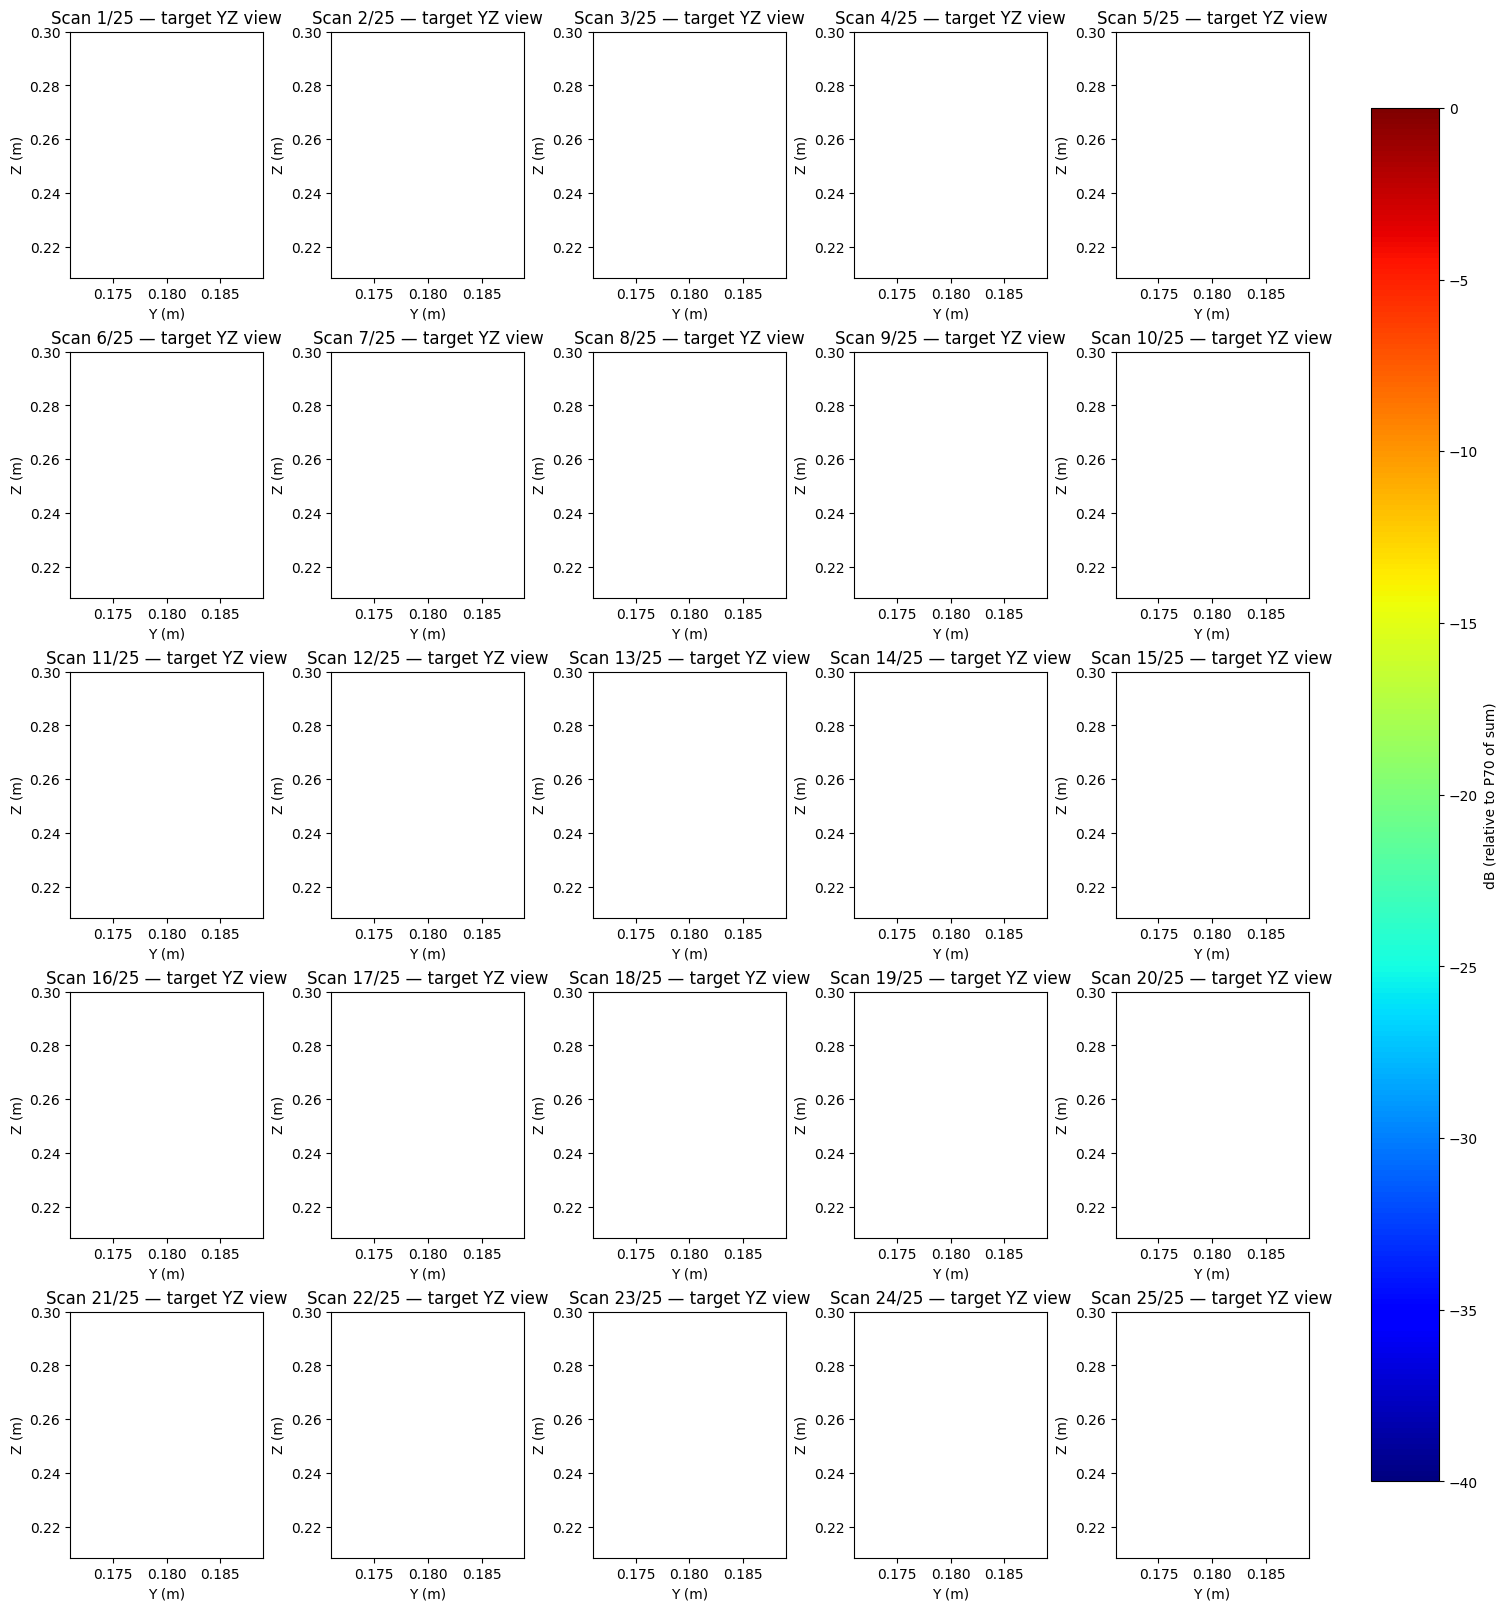

C:\Users\13523\AppData\Local\Temp\ipykernel_5984\4142573664.py:93: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.imshow(to_db(sum_yz), origin='lower', extent=extent, cmap='jet',


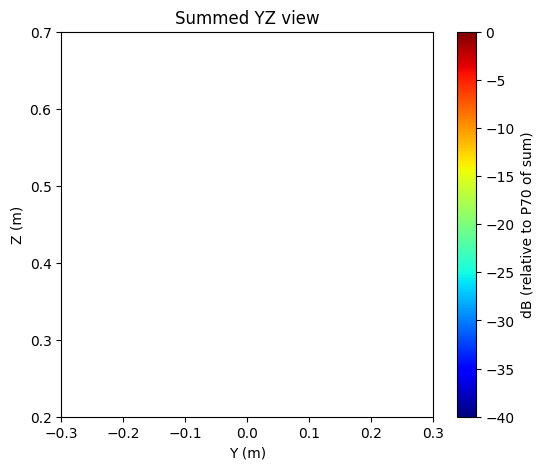

In [29]:
# quick sanity
# --- Extract axes from meta and coerce to Y(horizontal) / Z(vertical)
rows = np.asarray(meta["rows"])
cols = np.asarray(meta["cols"])
sliceName = meta.get("sliceName", "YZ")

# Determine which axis is Y and which is Z in the current image,
# then return image data so that axis-0 is Z (vertical) and axis-1 is Y (horizontal).
def yz_view(img2d, rows, cols, sliceName):
    # img2d shape: [len(rows), len(cols)]
    if sliceName == "YZ":
        # rows = Y, cols = Z  -> need transpose so vertical=Z, horizontal=Y
        return img2d.T, cols, rows   # z_axis, y_axis
    elif sliceName == "XZ":
        # rows = X, cols = Z  -> Y not present; we’ll label X as “Y” placeholder
        return img2d.T, cols, rows   # z_axis=Z, y_axis=X  (note: semantic mismatch)
    else:  # "XY"
        # rows = X, cols = Y  -> no Z; we’ll label X as “Z” placeholder
        return img2d, rows, cols     # z_axis=X, y_axis=Y  (note: semantic mismatch)

# Prepare stacks in YZ plotting orientation
R, C, N = y_stack.shape
imgs_yz = []
for i in range(N):
    img2d = y_stack[:,:,i]
    img_yz, z_axis, y_axis = yz_view(img2d, rows, cols, sliceName)
    imgs_yz.append(img_yz)
imgs_yz = np.stack(imgs_yz, axis=2)  # [Z, Y, N]

sum_yz, z_axis, y_axis = yz_view(y_sum, rows, cols, sliceName)

# --- Enforce requested bounds
# User-specified bounds:
ymin_req, ymax_req = -0.3, 0.3
zmin_req, zmax_req =  0.2, 0.7

# Clip axes to requested ranges (and find their min/max for extent)
y_mask = (y_axis >= ymin_req) & (y_axis <= ymax_req)
z_mask = (z_axis >= zmin_req) & (z_axis <= zmax_req)

# If bounds exceed available axis range, intersect with actual data
if not y_mask.any():  # fallback: use full axis
    y_mask = np.ones_like(y_axis, dtype=bool)
if not z_mask.any():
    z_mask = np.ones_like(z_axis, dtype=bool)

# Apply masks
imgs_yz = imgs_yz[z_mask][:, y_mask, :]
sum_yz  = sum_yz [z_mask][:, y_mask]
y_axis  = y_axis [y_mask]
z_axis  = z_axis [z_mask]

# Extent for imshow: [x_min, x_max, y_min, y_max] -> here x=Y, y=Z
extent = [float(y_axis.min()), float(y_axis.max()), float(z_axis.min()), float(z_axis.max())]

# --- dB scaling with fixed window
DR = 40  # dB range
ref = max(np.percentile(sum_yz, 10), 1e-12)  # robust reference (P70 of sum)
def to_db(a, ref=ref):
    a = np.maximum(a, 1e-12)
    return 20*np.log10(a / ref)

vmin, vmax = -DR, 0

# --- grid size for multiple scans
N = imgs_yz.shape[2]
ncols = int(np.ceil(np.sqrt(N)))
nrows = int(np.ceil(N/ncols))
if N == 25:
    nrows = ncols = 5

# --- plot individual scans (Y on horizontal, Z on vertical) ---
fig, axes = plt.subplots(nrows, ncols, figsize=(3.0*ncols, 3.2*nrows), constrained_layout=True)
axes = np.atleast_1d(axes).ravel()

for i in range(N):
    ax = axes[i]
    im = ax.imshow(to_db(imgs_yz[:,:,i]), origin='lower', extent=extent, cmap='jet',
                   vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_title(f"Scan {i+1}/{N} — target YZ view")
    ax.set_xlabel("Y (m)")
    ax.set_ylabel("Z (m)")

for j in range(N, len(axes)):
    fig.delaxes(axes[j])

cbar = fig.colorbar(im, ax=axes[:N], shrink=0.9)
cbar.set_label("dB (relative to P70 of sum)")
plt.show()

# --- summed image (YZ view) ---
plt.figure(figsize=(6,5))
plt.imshow(to_db(sum_yz), origin='lower', extent=extent, cmap='jet',
           vmin=vmin, vmax=vmax, aspect='auto')
plt.colorbar(label="dB (relative to P70 of sum)")
plt.title("Summed YZ view")
plt.xlabel("Y (m)")
plt.ylabel("Z (m)")
plt.xlim(ymin_req, ymax_req)
plt.ylim(zmin_req, zmax_req)
plt.show()

In [ ]:
#Optional save data

In [ ]:
data_path = os.path.join(save_dir, f"BackprojectionData_YZ_{timestamp}.npz")
np.savez(data_path, imgs_yz=imgs_yz, sum_yz=sum_yz, y_axis=y_axis, z_axis=z_axis,
         y_stack_original=y_stack, y_sum_original=y_sum, meta=meta)

print(f"Saved:\n- Grid plot: {grid_plot_path}\n- Summed plot: {sum_plot_path}\n- Data: {data_path}")